# Formative 2 – PCA
## Part 2: Choosing the number of components and making PCA faster

This notebook continues from `PCA_Formative2_Person1.ipynb`. Part 1 cleaned the Rwanda Seasonal Agricultural
Survey (2024 Season B) data and did PCA by hand. Here we do:

* **Task 2** – pick the number of principal components from the explained variance
* **Task 3** – make the PCA code faster and test it on bigger data

We only use `numpy` and `matplotlib`. The file is read with Python's built-in `csv` module.

In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt

## 1. Load the clean data from Part 1
`data/processed/sas_2024B_pca_ready.csv` has no missing values and every column is already a number.

In [2]:
with open("data/processed/sas_2024B_pca_ready.csv") as f:
    reader = csv.reader(f)
    feature_names = next(reader)
    X = np.array([[float(v) for v in row] for row in reader])

print("Shape:", X.shape)
print("Missing values:", np.isnan(X).sum())
print("Features:", feature_names)

Shape: (17260, 20)
Missing values: 0
Features: ['age', 'area', 'labour_cost', 'erosion_cost', 'irrigation_cost', 'erosion_level', 'anti_erosion', 'consolidated', 'machine', 'irrigated', 'gender_Female', 'gender_Organisation', 'province_East', 'province_North', 'province_South', 'province_West', 'stratum_large farm', 'stratum_marshland', 'stratum_mixed', 'stratum_rangeland']


## 2. Scale and run PCA (same steps as Part 1)
We z-score every column so that no feature wins just because of its units, then get the sorted eigenvalues
and eigenvectors of the covariance matrix.

In [3]:
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)

X_centered = X_scaled - X_scaled.mean(axis=0)
n = X_centered.shape[0]
cov_matrix = (X_centered.T @ X_centered) / (n - 1)

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

print("Eigenvalues (largest first):", eigenvalues.round(3))

Eigenvalues (largest first): [3.752 1.728 1.33  1.255 1.13  1.09  1.055 1.023 1.003 0.916 0.892 0.848
 0.842 0.784 0.764 0.668 0.339 0.284 0.232 0.065]


---
# Task 2: How many principal components?
### Step 1: Explained variance
Each eigenvalue is the variance along its principal component. Dividing it by the sum of all eigenvalues gives the
share of the total variance that the component explains. The cumulative sum tells us how much we keep if we use
the first k components.

In [4]:
explained = eigenvalues / eigenvalues.sum()
cumulative = np.cumsum(explained)

print(f"{'PC':<6}{'eigenvalue':>11}{'explained':>11}{'cumulative':>12}")
for i in range(len(eigenvalues)):
    print(f"PC{i+1:<4}{eigenvalues[i]:>11.3f}{explained[i]*100:>10.1f}%{cumulative[i]*100:>11.1f}%")

PC     eigenvalue  explained  cumulative
PC1         3.752      18.8%       18.8%
PC2         1.728       8.6%       27.4%
PC3         1.330       6.6%       34.0%
PC4         1.255       6.3%       40.3%
PC5         1.130       5.7%       46.0%
PC6         1.090       5.4%       51.4%
PC7         1.055       5.3%       56.7%
PC8         1.023       5.1%       61.8%
PC9         1.003       5.0%       66.8%
PC10        0.916       4.6%       71.4%
PC11        0.892       4.5%       75.9%
PC12        0.848       4.2%       80.1%
PC13        0.842       4.2%       84.3%
PC14        0.784       3.9%       88.2%
PC15        0.764       3.8%       92.1%
PC16        0.668       3.3%       95.4%
PC17        0.339       1.7%       97.1%
PC18        0.284       1.4%       98.5%
PC19        0.232       1.2%       99.7%
PC20        0.065       0.3%      100.0%


### Step 2: Scree plot and cumulative explained variance
The bars show how much each component explains on its own. The line shows the running total.

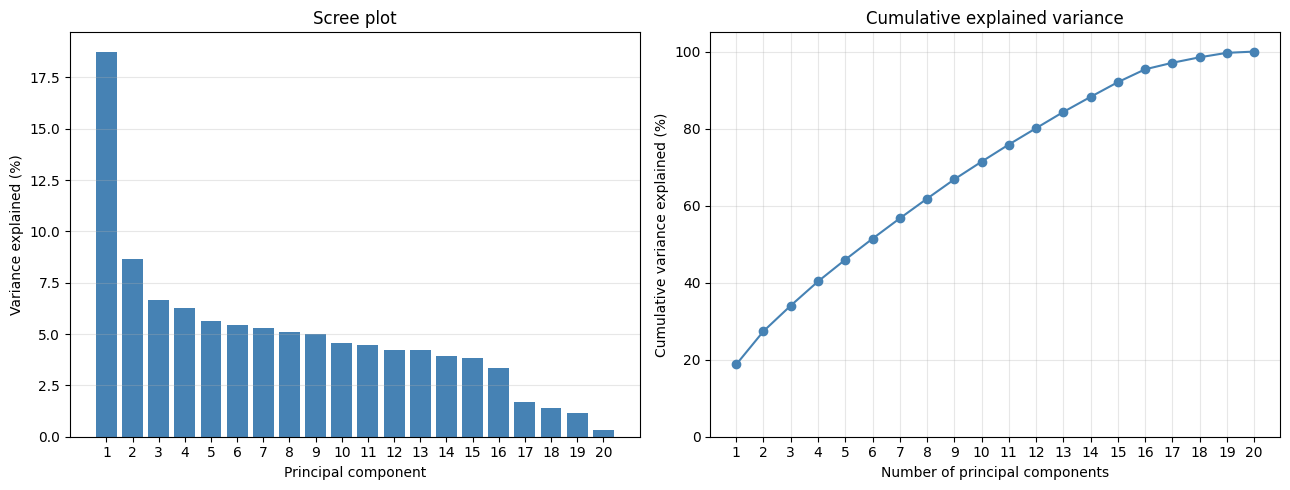

In [5]:
pcs = np.arange(1, len(eigenvalues) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.bar(pcs, explained * 100, color="steelblue")
ax1.set_xlabel("Principal component")
ax1.set_ylabel("Variance explained (%)")
ax1.set_title("Scree plot")
ax1.set_xticks(pcs)
ax1.grid(alpha=0.3, axis="y")

ax2.plot(pcs, cumulative * 100, marker="o", color="steelblue")
ax2.set_xlabel("Number of principal components")
ax2.set_ylabel("Cumulative variance explained (%)")
ax2.set_title("Cumulative explained variance")
ax2.set_xticks(pcs)
ax2.set_ylim(0, 105)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/explained_variance.png")
plt.show()